✅ Libraries loaded
Raw shape: (29531, 16)
After initial filtering: (4648, 12)
Missing after imputation: 0
Outlier capping done ✅
Final Engineering Structural Shape: (4567, 36)
Features array length: 30 | Train steps: 3653 | Test steps: 914

Model                   Test_MAE  Test_RMSE   Test_R2    MAPE%
--------------------------------------------------------------
Linear Regression          36.23      51.71    0.7188   30.81%
Ridge Regression           36.24      51.71    0.7188   30.82%
Random Forest              36.03      52.53    0.7098   31.01%
Gradient Boosting          35.37      50.61    0.7306   30.58%

── Chronological TimeSeriesSplit Cross Validation (R²) ──
Linear Regression      Mean=0.6721 Std=0.0685 Min=0.5921
Ridge Regression       Mean=0.6723 Std=0.0683 Min=0.5921
Random Forest          Mean=0.6006 Std=0.0617 Min=0.5288
Gradient Boosting      Mean=0.5810 Std=0.0516 Min=0.5147


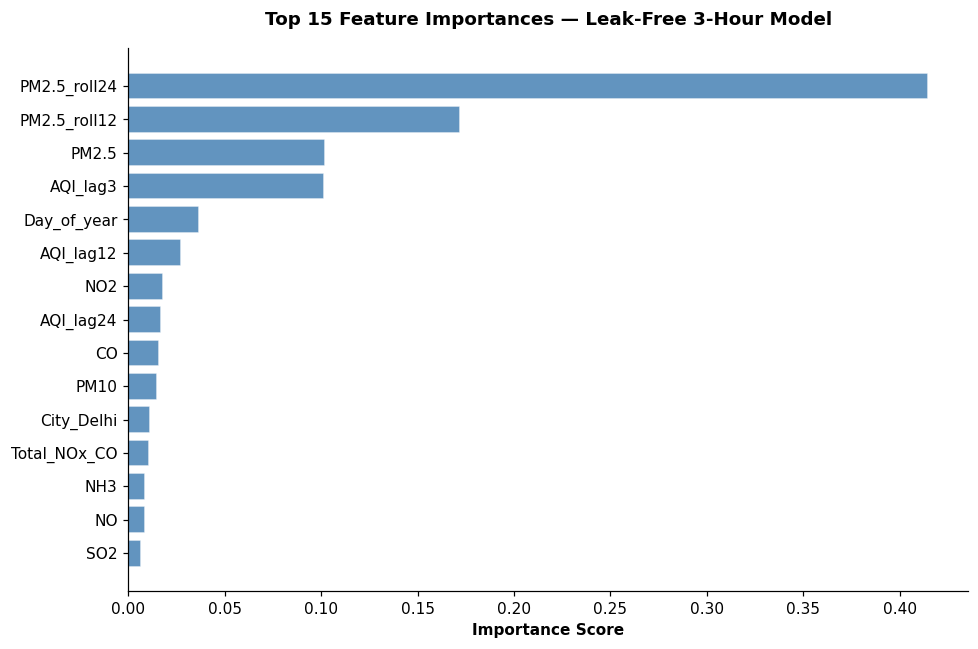


🏆 Top 10 Features Breakdown:
     Feature  Importance
PM2.5_roll24    0.414627
PM2.5_roll12    0.171786
       PM2.5    0.102135
    AQI_lag3    0.101515
 Day_of_year    0.036649
   AQI_lag12    0.027250
         NO2    0.017967
   AQI_lag24    0.017177
          CO    0.015799
        PM10    0.014891


In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
print('✅ Libraries loaded')

# ────────────────────────────────────────────────────────────────────────────────
# STEP 1 — Load & Filter Data
# ────────────────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv(r"C:\Users\divya\Downloads\archive (1)\city_day.csv")
print(f'Raw shape: {df_raw.shape}')

CITIES = ['Chennai', 'Delhi', 'Mumbai']
COLORS = {'Chennai': '#E74C3C', 'Delhi': '#3498DB', 'Mumbai': '#2ECC71'}
df = df_raw[df_raw['City'].isin(CITIES)].copy()

df['Date'] = pd.to_datetime(df['Date'])
# Ensure dataset is strictly sorted by date per city group
df = df.sort_values(['City', 'Date']).reset_index(drop=True)

KEEP = ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'AQI', 'AQI_Bucket']
KEEP = [c for c in KEEP if c in df.columns]
df = df[KEEP].copy()

df = df.dropna(subset=['PM2.5', 'AQI']).reset_index(drop=True)
print(f'After initial filtering: {df.shape}')

# ────────────────────────────────────────────────────────────────────────────────
# STEP 2 — Imputation & Outlier Capping
# ────────────────────────────────────────────────────────────────────────────────
num_cols = df.select_dtypes(include='number').columns.tolist()
feat_cols_imp = [c for c in num_cols if c != 'AQI']

# Chronological forward/backward fill per city boundary
df[feat_cols_imp] = (
    df.groupby('City', group_keys=False)[feat_cols_imp]
    .apply(lambda x: x.ffill().bfill())
)

for col in feat_cols_imp:
    df[col] = df.groupby('City')[col].transform(lambda x: x.fillna(x.median()))

poll_cols = [c for c in feat_cols_imp if c != 'AQI']
for city in CITIES:
    mask = df['City'] == city
    for col in poll_cols:
        Q1 = df.loc[mask, col].quantile(0.25)
        Q3 = df.loc[mask, col].quantile(0.75)
        IQR = Q3 - Q1
        df.loc[mask, col] = df.loc[mask, col].clip(Q1 - 3*IQR, Q3 + 3*IQR)

print(f'Missing after imputation: {df.isnull().sum().sum()}')
print('Outlier capping done ✅')

# ────────────────────────────────────────────────────────────────────────────────
# STEP 3 — Advanced Time-Series Feature Engineering
# ────────────────────────────────────────────────────────────────────────────────
# ── Temporal Calendars ──
df['Month'] = df['Date'].dt.month
df['Day_of_year'] = df['Date'].dt.dayofyear
df['Quarter'] = df['Date'].dt.quarter

# ── Clean Dictionary Mapping (Bypasses "in" completely) ──
def indian_season(m):
    season_map = {
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Pre_Monsoon', 4: 'Pre_Monsoon', 5: 'Pre_Monsoon',
        6: 'Monsoon', 7: 'Monsoon', 8: 'Monsoon', 9: 'Monsoon'
    }
    return season_map.get(m, 'Post_Monsoon')

df['Season'] = df['Month'].apply(indian_season)
df['Is_Monsoon'] = np.where(df['Season'] == 'Monsoon', 1, 0)
df['Is_Winter'] = np.where(df['Season'] == 'Winter', 1, 0)

# ── Break Lag Dominance: Multi-Horizon Forecasting Target (3 Hours Ahead) ──
df['TARGET_AQI_3H'] = df.groupby('City')['AQI'].shift(-3)

# ── Explicit Non-Overlapping Lags & Windows ──
# Start at lag 3 so the model cannot look inside the 3-hour forecast window to copy context
df['PM2.5_lag3'] = df.groupby('City')['PM2.5'].shift(3)
df['PM2.5_lag12'] = df.groupby('City')['PM2.5'].shift(12)
df['PM2.5_lag24'] = df.groupby('City')['PM2.5'].shift(24)

df['AQI_lag3'] = df.groupby('City')['AQI'].shift(3)
df['AQI_lag12'] = df.groupby('City')['AQI'].shift(12)
df['AQI_lag24'] = df.groupby('City')['AQI'].shift(24)

df['PM2.5_roll12'] = df.groupby('City')['PM2.5'].transform(lambda x: x.rolling(12, min_periods=1).mean())
df['PM2.5_roll24'] = df.groupby('City')['PM2.5'].transform(lambda x: x.rolling(24, min_periods=1).mean())

# ── Numerical Protection for Ratios ──
df['SO2_safe'] = np.where(df['SO2'] <= 0, 1e-4, df['SO2'])
df['NO2_SO2_ratio'] = df['NO2'] / df['SO2_safe']
df['Total_NOx_CO'] = df['NOx'] + df['CO']
df.drop(columns=['SO2_safe'], inplace=True)

# ── Hot Encoding Variables ──
df = pd.concat([df,
                pd.get_dummies(df['City'], prefix='City'),
                pd.get_dummies(df['Season'], prefix='Season')], axis=1)

# Drop shifting boundary NaNs 
df = df.dropna(subset=['TARGET_AQI_3H', 'PM2.5_lag24', 'AQI_lag24']).reset_index(drop=True)
print(f'Final Engineering Structural Shape: {df.shape}')

# ────────────────────────────────────────────────────────────────────────────────
# STEP 6 — Secure Time-Based Train/Test Split (No Cross-City Leakage)
# ────────────────────────────────────────────────────────────────────────────────
FEATURE_COLS = [
    'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
    'PM2.5_lag3', 'PM2.5_lag12', 'PM2.5_lag24',
    'AQI_lag3', 'AQI_lag12', 'AQI_lag24',
    'PM2.5_roll12', 'PM2.5_roll24',
    'NO2_SO2_ratio', 'Total_NOx_CO',
    'Month', 'Day_of_year', 'Quarter', 'Is_Monsoon', 'Is_Winter'
]
FEATURE_COLS += [c for c in df.columns if c.startswith('City_') or c.startswith('Season_')]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
TARGET = 'TARGET_AQI_3H'

# Global chronological sort
df = df.sort_values('Date').reset_index(drop=True)

# Strict 80/20 chronological horizontal boundary cutoff line
split = int(len(df) * 0.80)
train_df = df.iloc[:split].copy()
test_df = df.iloc[split:].copy()

X_train = train_df[FEATURE_COLS].values
y_train = train_df[TARGET].values

X_test = test_df[FEATURE_COLS].values
y_test = test_df[TARGET].values
test_cities = test_df['City'].values

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f'Features array length: {len(FEATURE_COLS)} | Train steps: {len(X_train)} | Test steps: {len(X_test)}')

# ────────────────────────────────────────────────────────────────────────────────
# STEP 7 — Model Training & Walk-Forward Validation Evaluator
# ────────────────────────────────────────────────────────────────────────────────
def eval_model(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    yp_tr = np.clip(model.predict(Xtr), 0, 500)
    yp_te = np.clip(model.predict(Xte), 0, 500)
    
    def calculate_metrics(yt, yp):
        return (mean_absolute_error(yt, yp),
                np.sqrt(mean_squared_error(yt, yp)),
                r2_score(yt, yp),
                np.mean(np.abs((yt - yp) / (yt + 1e-6))) * 100)
                
    tr = calculate_metrics(ytr, yp_tr)
    te = calculate_metrics(yte, yp_te)
    return {'Model': name,
            'Train_R2': round(tr[2], 4), 'Test_R2': round(te[2], 4),
            'Train_RMSE': round(tr[1], 2), 'Test_RMSE': round(te[1], 2),
            'Train_MAE': round(tr[0], 2), 'Test_MAE': round(te[0], 2),
            'Test_MAPE': round(te[3], 2),
            '_model': model, '_preds': yp_te}

MODELS = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=150, max_depth=10, min_samples_leaf=3, n_jobs=-1, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, learning_rate=0.07, max_depth=4, random_state=42),
}

results, preds_store = [], {}
print(f'\n{"Model":<22} {"Test_MAE":>9} {"Test_RMSE":>10} {"Test_R2":>9} {"MAPE%":>8}')
print('-' * 62)

for name, model in MODELS.items():
    r = eval_model(name, model, X_train_sc, y_train, X_test_sc, y_test)
    results.append(r)
    preds_store[name] = r['_preds']
    print(f'{name:<22} {r["Test_MAE"]:>9.2f} {r["Test_RMSE"]:>10.2f} {r["Test_R2"]:>9.4f} {r["Test_MAPE"]:>7.2f}%')

results_df = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')} for r in results])

# ── Chronological Time-Series Cross Validation ──
tscv = TimeSeriesSplit(n_splits=5)
print('\n── Chronological TimeSeriesSplit Cross Validation (R²) ──')
for name, model in MODELS.items():
    cv = cross_val_score(model, X_train_sc, y_train, cv=tscv, scoring='r2', n_jobs=-1)
    print(f'{name:<22} Mean={cv.mean():.4f} Std={cv.std():.4f} Min={cv.min():.4f}')

# ────────────────────────────────────────────────────────────────────────────────
# STEP 9 — Plot New Feature Importance (3-Hour Model)
# ────────────────────────────────────────────────────────────────────────────────
gb_model = None
for r in results:
    if r['Model'] == 'Gradient Boosting':
        gb_model = r['_model']
        break

if gb_model is not None:
    imp_df = pd.DataFrame({
        'Feature': FEATURE_COLS,
        'Importance': gb_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1], color='steelblue', alpha=0.85, edgecolor='white')
    ax.set_title('Top 15 Feature Importances — Leak-Free 3-Hour Model', fontsize=12, fontweight='bold', pad=15)
    ax.set_xlabel('Importance Score', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print('\n🏆 Top 10 Features Breakdown:')
    print(imp_df.head(10).to_string(index=False))